# Laboratorio: Clasificación de Variedades de Fríjoles Secos

**Dataset:** Dry Bean Dataset (UCI ML Repository, ID 602)  
**Problema:** Clasificación multiclase — predecir la variedad de fríjol a partir de características morfológicas.  
**Modelos evaluados:** Logistic Regression (baseline) · Random Forest

---


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

import joblib

## 1. Carga del Dataset

Se obtiene el dataset directamente desde el repositorio UCI usando `ucimlrepo` y se guarda una copia en `data/raw/`.


In [2]:
dry_bean = fetch_ucirepo(id=602)
X = dry_bean.data.features
y = dry_bean.data.targets
df = pd.concat([X, y], axis=1)

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
#guardamos los datos en data/raw
df.to_csv("../data/raw/dry_bean_data.csv")

## 2. Exploración de Datos (EDA)

Revisión general del dataset: dimensiones, tipos de variables, estadísticas descriptivas y preguntas clave sobre la estructura de los datos.


**Preguntas**

1. ¿Cuántas columnas tiene el dataset? -> El dataset tiene 17 columnas.
3. ¿Cuál es la variable objetivo? -> La variable objetivo es Class, que indica la variedad de los fríjoles. 
4. ¿El problema es de clasificación o regresión? -> En este caso es un problema de clasificación, porque queremos determinar la variedad de un frijol a partir de las características que se le presenten al modelo.

In [4]:
print(df.shape)
print(df.info())
df.describe().T

(13611, 17)
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860154
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRatio,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


### 2.1 Detección de Valores Atípicos (IQR)


In [5]:
## Detección de valores atípicos en el dataset usando la técnica IQR
numeric_cols = df.select_dtypes(include='number').columns
outliers_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    

    outliers_dict[col] = outliers


all_outliers = pd.concat(outliers_dict.values()).drop_duplicates()
print("Todos los outliers detectados en el DataFrame:")
display(all_outliers)

Todos los outliers detectados en el DataFrame:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
3344,100846,1297.770,469.285655,274.423910,1.710076,0.811200,102015,358.331013,0.792036,0.988541,0.752442,0.763567,0.004653,0.000976,0.583034,0.997033,BARBUNYA
3345,102015,1271.970,456.791895,286.894421,1.592195,0.778162,103901,360.401904,0.804973,0.981848,0.792356,0.788985,0.004478,0.001070,0.622497,0.991137,BARBUNYA
3346,102379,1296.377,456.722068,286.557574,1.593823,0.778679,104111,361.044307,0.739412,0.983364,0.765523,0.790512,0.004461,0.001075,0.624909,0.995995,BARBUNYA
3347,105542,1265.623,466.135980,288.999342,1.612931,0.784610,107112,366.579116,0.747888,0.985342,0.827993,0.786421,0.004417,0.001042,0.618458,0.997530,BARBUNYA
3348,115967,1359.763,449.454969,331.305270,1.356619,0.675755,118497,384.257427,0.742712,0.978649,0.788166,0.854941,0.003876,0.001277,0.730924,0.991585,BARBUNYA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9912,52034,865.331,320.323294,210.418311,1.522317,0.753983,52543,257.394146,0.663775,0.990313,0.873238,0.803545,0.006156,0.001583,0.645684,0.982936,SIRA
10238,24667,591.758,214.532799,148.550306,1.444176,0.721479,25110,177.220202,0.701684,0.982358,0.885193,0.826075,0.008697,0.002498,0.682400,0.985506,DERMASON
10302,25276,600.507,224.482131,145.969269,1.537873,0.759721,25798,179.394545,0.727995,0.979766,0.880810,0.799148,0.008881,0.002234,0.638638,0.982144,DERMASON
11043,28972,651.728,244.274283,153.091204,1.595613,0.779246,29496,192.063261,0.660285,0.982235,0.857148,0.786261,0.008431,0.001988,0.618206,0.986417,DERMASON


**Este dataset tiene:**

- 13611 registros.
- 17 variables, siendo class en este caso la variable a predecir.
- Casi en su totalidad datos numéricos, excepto por la cariable **Class** que es categórica.
- De los 13611 registors del dataset, usando el método IQR, existen 2991 registros con valores atípicos, no necesariamente se deben remover porque pueden aportar riqueza de variedad para entrenar nuestro modelo.

### 2.2 Calidad del Dataset — Valores Nulos y Duplicados

Antes de continuar con el análisis, se verifica si el dataset contiene **valores faltantes** o **filas duplicadas**, ya que ambos pueden distorsionar los resultados del modelo.

- **Valores nulos:** indican registros incompletos que podrían sesgar el entrenamiento.
- **Duplicados:** pueden inflar artificialmente el rendimiento si aparecen en ambos conjuntos (entrenamiento y prueba), lo que constituye una filtración de datos (*data leakage*).


In [6]:
missing_values = df.isna().sum()
duplicated_rows = df.duplicated().sum()
print(missing_values)
print("Filas duplicadas:", duplicated_rows)

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64
Filas duplicadas: 68


In [7]:
df = df.drop_duplicates()

### 2.3 Distribución de Clases

Se analiza cuántos registros hay por variedad de fríjol para detectar posibles **desequilibrios de clase** (*class imbalance*).

Un desbalance significativo puede hacer que el modelo aprenda mejor las clases mayoritarias y tenga bajo desempeño en las minoritarias. Esto es clave para elegir la métrica de evaluación adecuada — en este caso se usa **F1 macro**, que pondera por igual todas las clases independientemente de su frecuencia.


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


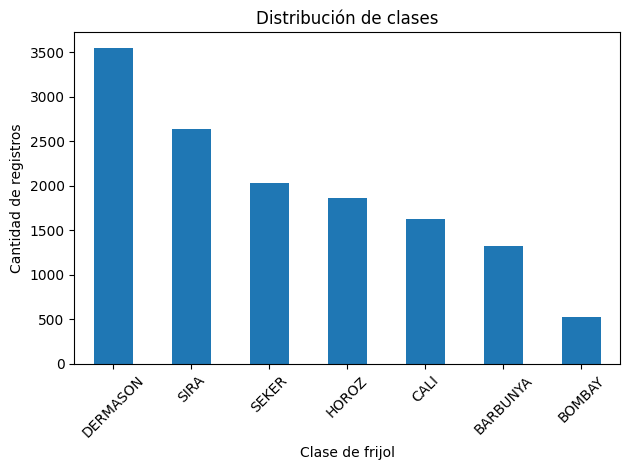

In [8]:
class_counts = df["Class"].value_counts()
print(class_counts)

class_counts.plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase de frijol")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Las clases no están balanceadas — en el caso más extremo, la muestra de fríjoles Dermason es alrededor de 7 veces más grande que la de la variedad Bombay. Esto puede afectar al modelo haciendo que se ajuste mejor para predecir las variedades con mayor cantidad de muestras y que tenga bajo desempeño en las minoritarias. Por eso es clave elegir métricas que reflejen el rendimiento en todas las clases por igual.

## 3. Reducción de Dimensionalidad (PCA)

El dataset original contiene 16 características numéricas, muchas de ellas altamente correlacionadas entre sí (e.g., área, perímetro, longitud de ejes). Aplicar **Análisis de Componentes Principales (PCA)** permite:

- Eliminar la redundancia entre variables correlacionadas.
- Reducir el costo computacional del entrenamiento.
- Evitar problemas de *multicolinealidad* en modelos lineales.

Se estandarizan los datos primero (media 0, varianza 1) ya que PCA es sensible a la escala, y luego se seleccionan los **4 componentes principales** que explican más del 95 % de la varianza total. El resultado se guarda en `data/processed/` para uso posterior.


In [11]:
# Standardizing the data
df_scaled = StandardScaler().fit_transform(df.drop(['Class'], axis=1))

# Apply PCA
pca = PCA(n_components=4)  # iterating the number of components to achieve 95% explained variation
df_pca = pca.fit_transform(df_scaled)

# Proportion of variance explained by each principal component
explained_variance_ratio = pca.explained_variance_ratio_

# Cumulative variance explained
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Print the results
for i in range(len(explained_variance_ratio)):
    print(f"Principal Component {i+1}: Explained Variance = {explained_variance_ratio[i]:.4f}, Cumulative Variance = {cumulative_variance_ratio[i]:.4f}")

Principal Component 1: Explained Variance = 0.5555, Cumulative Variance = 0.5555
Principal Component 2: Explained Variance = 0.2636, Cumulative Variance = 0.8191
Principal Component 3: Explained Variance = 0.0798, Cumulative Variance = 0.8989
Principal Component 4: Explained Variance = 0.0511, Cumulative Variance = 0.9500


In [17]:
# Guardamos datos procesados

# Convertir el array de PCA en DataFrame
df_pca = pd.DataFrame(df_pca, 
                         columns=[f"PC{i+1}" for i in range(df_pca.shape[1])])

# Si quieres conservar también la columna 'Class'
df_pca['Class'] = df['Class'].values

# Guardar en CSV
df_pca.to_csv("../data/processed/dry_beans_pca.csv", index=False)

## 4. Preparación para el Modelado — División Entrenamiento / Prueba

Se separan las features (`X`) de la variable objetivo (`y`) y se divide el dataset en **80 % entrenamiento** y **20 % prueba** usando `train_test_split`.

El parámetro `stratify=y` garantiza que la proporción de cada variedad de fríjol se mantenga igual en ambos subconjuntos, evitando que el desbalance de clases quede concentrado en uno solo de los grupos.


In [18]:
X = df_pca.drop(columns="Class")
y = df_pca["Class"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split( 
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

## 5. Modelo Baseline — Regresión Logística

Como punto de partida se entrena una **Regresión Logística** envuelta en un `Pipeline` de scikit-learn que incluye estandarización. Esto establece un piso de referencia mínimo: cualquier modelo más complejo debe superar estas métricas para justificar su mayor costo computacional.

Se usa `max_iter=1000` para asegurar convergencia con 7 clases y se fija `random_state=42` para reproducibilidad.


In [20]:
baseline_model = Pipeline(steps=[ 
    ("scaler", StandardScaler()), 
    ("classifier", 
     LogisticRegression(max_iter=1000, random_state=42)) 
]) 

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

In [21]:
y_pred_baseline = baseline_model.predict(X_test)

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average="macro")

print("Accuracy baseline:", accuracy_baseline)
print("F1 macro baseline:", f1_baseline)
print(classification_report(y_test, y_pred_baseline))

Accuracy baseline: 0.8863049095607235
F1 macro baseline: 0.8891490255105756
              precision    recall  f1-score   support

    BARBUNYA       0.81      0.71      0.76       265
      BOMBAY       1.00      0.99      1.00       104
        CALI       0.80      0.87      0.83       326
    DERMASON       0.92      0.90      0.91       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.92      0.93      0.93       406
        SIRA       0.84      0.88      0.86       527

    accuracy                           0.89      2709
   macro avg       0.89      0.89      0.89      2709
weighted avg       0.89      0.89      0.89      2709



¿Por qué F1 macro puede ser más informativo que accuracy cuando las clases no están perfectamente balanceadas?

El accuracy pesa cada predicción por igual, por lo que un modelo que acierte siempre en las clases mayoritarias (Dermason, Sira, Seker) puede reportar un valor alto aunque falle sistemáticamente en clases pequeñas como Bombay. F1 macro calcula el F1 de cada clase por separado y los promedia sin tener en cuenta su frecuencia, dando el mismo peso a Bombay que a Dermason. Es una métrica más honesta cuando el desbalance entre clases es significativo, que es precisamente el caso aquí.


In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    xticks_rotation=45
)

plt.title("Matriz de confusión - Logistic Regression")
plt.tight_layout()
plt.show()


## 6. Modelo Avanzado — Random Forest

Se entrena un **Random Forest** con 200 árboles de decisión. Al ser un ensemble que promedia múltiples árboles, es más robusto al ruido y captura relaciones no lineales que la regresión logística no puede modelar.

El parámetro `class_weight="balanced"` ajusta automáticamente los pesos inversamente proporcionales a la frecuencia de cada clase, compensando el desbalance detectado en el EDA sin necesidad de remuestrear el dataset.


In [22]:
forest_model = RandomForestClassifier( 
    n_estimators=200, 
    random_state=42, 
    class_weight="balanced" 
) 

forest_model.fit(X_train, y_train) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
y_pred_forest = forest_model.predict(X_test) 

accuracy_forest = accuracy_score(y_test, y_pred_forest) 
f1_forest = f1_score(y_test, y_pred_forest, average="macro") 

print("Accuracy Random Forest:", accuracy_forest) 
print("F1 macro Random Forest:", f1_forest) 
print(classification_report(y_test, y_pred_forest)) 

Accuracy Random Forest: 0.8866740494647471
F1 macro Random Forest: 0.8908326735563102
              precision    recall  f1-score   support

    BARBUNYA       0.83      0.71      0.77       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.79      0.87      0.83       326
    DERMASON       0.90      0.91      0.91       709
       HOROZ       0.96      0.93      0.94       372
       SEKER       0.93      0.93      0.93       406
        SIRA       0.85      0.86      0.85       527

    accuracy                           0.89      2709
   macro avg       0.89      0.89      0.89      2709
weighted avg       0.89      0.89      0.89      2709



## 7. Evaluación Comparativa — Fase de Evaluación CRISP-DM

En esta fase de CRISP-DM se decide qué modelo pasa a despliegue. La tabla siguiente resume las métricas de ambos modelos. El criterio recomendado es:

- Priorizar `f1_macro` sobre accuracy dado el desbalance de clases.
- Revisar los errores por clase en la matriz de confusión.
- Preferir el modelo más simple si el desempeño es muy similar (principio de parsimonia).

El modelo seleccionado es Random Forest, ya que supera a Logistic Regression tanto en accuracy como en F1 macro, y el uso de `class_weight="balanced"` lo hace más robusto frente al desbalance de clases presente en el dataset.


In [24]:
results = pd.DataFrame({ 
    "modelo": ["Logistic Regression", "Random Forest"], 
    "accuracy": [accuracy_baseline, accuracy_forest], 
    "f1_macro": [f1_baseline, f1_forest] 
}) 

print(results)

                modelo  accuracy  f1_macro
0  Logistic Regression  0.886305  0.889149
1        Random Forest  0.886674  0.890833


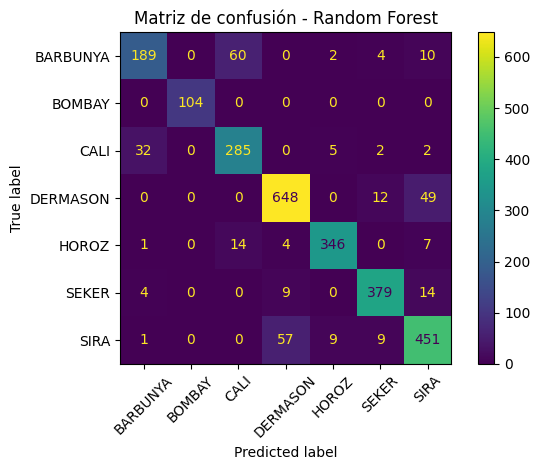

In [25]:
ConfusionMatrixDisplay.from_predictions( 
    y_test, 
    y_pred_forest, 
    xticks_rotation=45 
) 

plt.title("Matriz de confusión - Random Forest") 
plt.tight_layout() 
plt.show() 

Las clases que más se confunden entre sí son Sira y Dermason, y en menor medida Barbunya y Cali. Sira y Dermason comparten rangos muy parecidos de área, perímetro y longitud de eje mayor, lo que las hace difíciles de separar incluso en el espacio PCA. Barbunya y Cali se solapan en variables de forma como la solidez y la excentricidad. Bombay, en cambio, es morfológicamente la más distinta — es notablemente más grande en área y perímetro — por lo que suele clasificarse con alta precisión.

## 8. Importancia de Variables

Random Forest asigna a cada variable una importancia basada en cuánto reduce la impureza de los nodos al usarla para hacer particiones. Esto ayuda a identificar qué características geométricas son más discriminativas entre variedades. La importancia indica utilidad dentro del modelo entrenado, no causalidad — una variable puede aparecer como importante simplemente porque está correlacionada con otra más relevante biológicamente.


In [26]:
feature_importance = pd.DataFrame({ 
    "feature": X.columns, 
    "importance": forest_model.feature_importances_ 
}) 

feature_importance = feature_importance.sort_values(
    by="importance", 
    ascending=False ) 

print(feature_importance.head(10)) 

  feature  importance
1     PC2    0.437683
0     PC1    0.407573
3     PC4    0.078502
2     PC3    0.076243


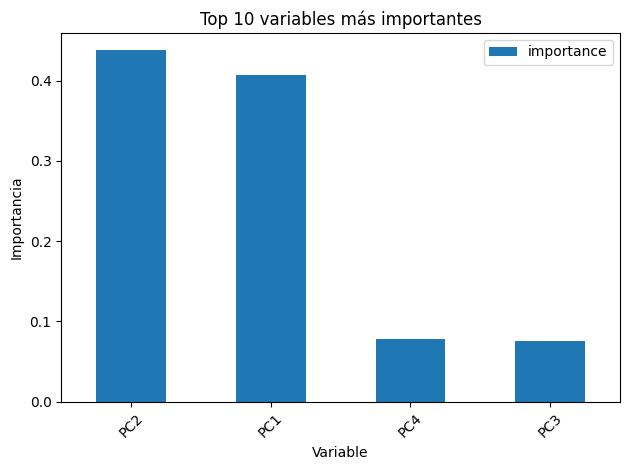

In [27]:
feature_importance.head(10).plot( 
    x="feature", 
    y="importance", 
    kind="bar" 
) 

plt.title("Top 10 variables más importantes") 
plt.xlabel("Variable") 
plt.ylabel("Importancia") 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

In [28]:
joblib.dump(forest_model, "../outputs/models/random_forest_drybean.joblib")

['../outputs/models/random_forest_drybean.joblib']

## 9. Verificación del Modelo Guardado

Una vez serializado el modelo con `joblib`, se carga desde disco y se prueba sobre varias muestras del conjunto de prueba. Este paso verifica que el artefacto guardado es funcional y reproduce las mismas predicciones — cualquier persona con acceso al repositorio puede cargarlo y obtener los mismos resultados sin re-entrenar, lo que es un requisito central de reproducibilidad en TDSP.


In [29]:
loaded_model = joblib.load("../outputs/models/random_forest_drybean.joblib")

for i in range(10):
    sample = X_test.iloc[[i]] 
    prediction = loaded_model.predict(sample) 
    
    print(f"Predicción de muestra {i}:", prediction[0]) 
    print(f"Valor real de muestra {i}:", y_test.iloc[0])
    print("\n")

Predicción de muestra 0: SEKER
Valor real de muestra 0: SEKER


Predicción de muestra 1: DERMASON
Valor real de muestra 1: SEKER


Predicción de muestra 2: DERMASON
Valor real de muestra 2: SEKER


Predicción de muestra 3: HOROZ
Valor real de muestra 3: SEKER


Predicción de muestra 4: SEKER
Valor real de muestra 4: SEKER


Predicción de muestra 5: SIRA
Valor real de muestra 5: SEKER


Predicción de muestra 6: DERMASON
Valor real de muestra 6: SEKER


Predicción de muestra 7: DERMASON
Valor real de muestra 7: SEKER


Predicción de muestra 8: BARBUNYA
Valor real de muestra 8: SEKER


Predicción de muestra 9: DERMASON
Valor real de muestra 9: SEKER




## 10. Mini Despliegue — Función Reutilizable

Esta función encapsula la lógica de predicción en una interfaz reutilizable. Representa la fase de Despliegue en CRISP-DM: el modelo ya puede recibir datos nuevos y devolver una predicción de forma programática. En un proyecto real, esta función sería el núcleo de una API, un servicio en la nube o una herramienta de control de calidad integrada al proceso de clasificación de granos.


In [30]:
def predict_bean_class(model, input_data): 
    prediction = model.predict(input_data) 
    return prediction[0] 
    
example_prediction = predict_bean_class(loaded_model, sample) 
print(example_prediction) 

DERMASON


---

## Reflexiones Finales

1. ¿Qué fase de CRISP-DM fue más importante en este laboratorio?  
La comprensión de datos fue la más determinante: detectar el desbalance de clases definió la elección de `class_weight="balanced"` en Random Forest y el uso de F1 macro como métrica principal. Sin ese análisis, el modelo podría haberse evaluado de forma engañosa con un accuracy inflado.

2. ¿Qué ventaja ofrece TDSP frente a trabajar con archivos desordenados?  
TDSP impone una estructura de carpetas estándar (`data/raw/`, `data/processed/`, `outputs/models/`) que hace el proyecto reproducible y auditable. Cualquier integrante del equipo puede entender qué hay en cada carpeta sin necesidad de explicación adicional.

3. ¿Cómo ayuda Scrum ML cuando el resultado del modelo es incierto?  
Los sprints cortos permiten entregar resultados parciales y ajustar el rumbo rápidamente. Si el baseline no era suficiente, el equipo pudo definir un nuevo sprint para explorar Random Forest en lugar de comprometerse con un plan rígido desde el inicio.

4. ¿Por qué se usa un modelo baseline?  
El baseline establece un piso mínimo de rendimiento. Si un modelo más complejo no lo supera, no justifica su mayor costo computacional ni de interpretabilidad. Si Random Forest no mejorara significativamente sobre regresión logística, la regresión logística sería la elección correcta.

5. ¿Qué métrica usarías para escoger el mejor modelo y por qué?  
F1 macro, porque el dataset tiene clases desbalanceadas. El accuracy puede ser engañoso cuando las clases mayoritarias dominan el resultado; F1 macro pondera todas las clases por igual independientemente de su frecuencia.

6. ¿Qué harías si una clase tiene muchos más errores que las demás?  
Depende de la causa: se puede aumentar el peso de esa clase con `class_weight`, aplicar técnicas de remuestreo como SMOTE, o recolectar más datos de esa variedad. También vale revisar si las características disponibles son suficientes para distinguirla — si dos variedades son geométricamente muy similares puede necesitarse información adicional.

7. ¿Qué información necesitarías antes de llevar este modelo a producción?  
- Rendimiento en datos recientes (el dataset UCI puede estar desactualizado).  
- Cómo se generarán las características en producción: el pipeline de visión por computador que extrae las medidas del grano desde imágenes reales.  
- Latencia y recursos computacionales disponibles en el entorno de despliegue.  
- Criterios de re-entrenamiento cuando el rendimiento empiece a degradar.  
- Aprobación del Product Owner y Definition of Done para despliegue productivo.
